In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

from src.data_loader import load_core_tables, save_by_trade_date, load_saved_factor_outputs
from src.data_processor import add_next_return_label
from src.factor_comp import compute_all_factors
from src.factor_eval import evaluate_factor, plot_ic_curve, plot_group_nav
from src.factor_return import run_factor_return_pipeline
from src.factor_return_v2 import run_factor_return_pipeline_v2
from src.risk_model_service import build_risk_matrices_for_date,build_risk_snapshots_for_rebalance_dates
from src.risk_specific import to_specific_returns_wide


import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)


pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)

In [9]:
# ====== 配置区 ======
BASE_DIR = Path('F:/RYSE_Database')  # 可改为绝对路径
OUTPUT_ROOT = Path(r'./output')  # 可改为相对路径

CONFIG = {
    'momentum_mode': 'C',  # A/B/C
    'sentiment_mode': 'C',  # A/B/C
    'enable_eval': True,
    'sentiment_csv': (
        str(BASE_DIR / 'Sentiment_Pred_EP_chg.csv'),
        str(BASE_DIR / 'Sentiment_Pred_EPS_chg.csv'),
    ),
}

TABLE_SOURCES = {
    'ashareeodderivativeindicator': {
        'path': str(BASE_DIR / 'ashareeodderivativeindicator'),
        'type': 'pkl_dir',
        'required': ['stock_code', 'trade_date']
    },
    'asharefinancialindicator': {
        'path': str(BASE_DIR / 'asharefinancialindicator'),
        'type': 'pkl_dir',
        'rename': {'ann_dt': 'trade_date'},
        'required': ['stock_code', 'trade_date']
    },
    'asharebalancesheet': {
        'path': str(BASE_DIR / 'asharebalancesheet'),
        'type': 'pkl_dir',
        'rename': {'ann_dt': 'trade_date'},
        'required': ['stock_code', 'trade_date']
    },
    'asharecashflow': {
        'path': str(BASE_DIR / 'asharecashflow'),
        'type': 'pkl_dir',
        'rename': {'ann_dt': 'trade_date'},
        'required': ['stock_code', 'trade_date']
    },
    'ashareincome': {
        'path': str(BASE_DIR / 'ashareincome'),
        'type': 'pkl_dir',
        'rename': {'ann_dt': 'trade_date'},
        'required': ['stock_code', 'trade_date']
    },
    'ashareciticsindustry': {
        'path': str(BASE_DIR / 'ashareciticsindustry'),
        'type': 'pkl_dir',
        'required': ['stock_code', 'trade_date']
    },
    'aindexeodprices': {
        'path': str(BASE_DIR / 'aindexeodprices'),
        'type': 'pkl_dir',
        'rename': {'index_code': 'stock_code'},
        'required': ['stock_code', 'trade_date']
    },
    'pctchange': {
        'path': str(BASE_DIR / 'pctchange.csv'),
        'type': 'csv',
        'required': ['stock_code', 'trade_date', 'pctchange']
    },
    'FY0': {
        'path': str(BASE_DIR / 'ashareconsensusrollingdata' / 'FY0'),
        'type': 'pkl_dir',
        'rename': {'est_dt': 'trade_date'}
    },
    'FY1': {
        'path': str(BASE_DIR / 'ashareconsensusrollingdata' / 'FY1'),
        'type': 'pkl_dir',
        'rename': {'est_dt': 'trade_date'}
    },
    'FY3': {
        'path': str(BASE_DIR / 'ashareconsensusrollingdata' / 'FY3'),
        'type': 'pkl_dir',
        'rename': {'est_dt': 'trade_date'}
    },
}

OUTPUT_DIR_MAP = {
    'Size': OUTPUT_ROOT / 'Size_Portfolio',
    'Volatility': OUTPUT_ROOT / 'Volatility_Portfolio',
    'Liquidity': OUTPUT_ROOT / 'Liquidity_Portfolio',
    'Momentum_A': OUTPUT_ROOT / 'Momentum_Portfolio',
    'Momentum_B': OUTPUT_ROOT / 'Momentum_CNE6',
    'Momentum_Portfolio': OUTPUT_ROOT / 'Momentum_Portfolio',
    'Momentum_CNE6': OUTPUT_ROOT / 'Momentum_CNE6',
    'Leverage': OUTPUT_ROOT / 'Leverage_Portfolio',
    'Earnings_Variability': OUTPUT_ROOT / 'Earnings_Variability',
    'Earnings_Quality': OUTPUT_ROOT / 'Earnings_Quality',
    'Profitability': OUTPUT_ROOT / 'Profitability',
    'Investment_Quality': OUTPUT_ROOT / 'Investment_Quality',
    'BTOP': OUTPUT_ROOT / 'BTOP_Portfolio',
    'Earnings_Yield': OUTPUT_ROOT / 'Earnings Yield_Portfolio',
    'Long_term_reversal': OUTPUT_ROOT / 'Long_term_reversal',
    'Growth': OUTPUT_ROOT / 'Growth_Portfolio',
    'Sentiment': OUTPUT_ROOT / 'Sentiment',
    'Dividend': OUTPUT_ROOT / 'Dividend',
}


# 回测开关配置
# 1) 只回测指定因子名单（output 目录名）
ENABLE_FACTOR_FILTER = True
TARGET_FACTORS = ['Size', 'Momentum_CNE6']  # 例如 ['Size', 'Momentum_CNE6']

# 2) 只回测指定时间段
ENABLE_DATE_FILTER = True
BT_START = '2018-01-01'
BT_END = '2021-12-31'
BT_BUFFER_DAYS = 30  # 读取收益时在起止日期前后各扩展天数

In [16]:
# ====== 加载与主计算 ======
tables = load_core_tables(TABLE_SOURCES)

In [ ]:
# 为评估准备 next-return 标签
tables['pctchange'] = add_next_return_label(tables['pctchange'])

factors = compute_all_factors(
    tables=tables,
    momentum_mode=CONFIG['momentum_mode'],
    sentiment_mode=CONFIG['sentiment_mode'],
    sentiment_csv=CONFIG['sentiment_csv'],
)

print('已计算因子数量:', len(factors))
list(factors.keys())[:20]

In [5]:
# ====== 落盘 ======
saved = []
for name, df in factors.items():
    out_dir = OUTPUT_DIR_MAP.get(name)
    if out_dir is None:
        continue
    if {'trade_date', 'stock_code'}.issubset(df.columns):
        last_file = save_by_trade_date(df, out_dir)
        saved.append((name, str(last_file)))

saved_df = pd.DataFrame(saved, columns=['factor', 'last_saved_file'])
display(saved_df)

,factor,last_saved_file
0,Size,output\Size_Portfolio\2024-05-27.pkl
1,Liquidity,output\Liquidity_Portfolio\2024-05-27.pkl
2,Leverage,output\Leverage_Portfolio\2024-05-27.pkl
3,Earnings_Quality,output\Earnings_Quality\2024-05-24.pkl
4,Profitability,output\Profitability\2024-05-24.pkl
5,Investment_Quality,output\Investment_Quality\2024-05-27.pkl
6,BTOP,output\BTOP_Portfolio\2024-05-27.pkl
7,Earnings_Yield,output\Earnings Yield_Portfolio\2024-05-27.pkl
8,Growth,output\Growth_Portfolio\2024-05-27.pkl
9,Dividend,output\Dividend\2024-05-27.pkl


In [ ]:
# ====== 因子评估（可选）======
if CONFIG['enable_eval']:
    eval_results = {}
    for name, df in factors.items():
        if not {'stock_code', 'trade_date'}.issubset(df.columns):
            continue
        candidates = [c for c in ['Size','Volatility','Liquidity','Momentum','Leverage','Earnings_Variability','Earnings_Quality','Profitability','InvestmentQuality','BTOP','Earnings_Yield','Long_term_reversal','Growth','Sentiment','Dividend'] if c in df.columns]
        if not candidates:
            continue
        factor_col = candidates[0]
        eval_df = df.merge(tables['pctchange'][['stock_code','trade_date','pctchange','icfactor']], on=['stock_code','trade_date'], how='left')
        eval_df = eval_df.dropna(subset=[factor_col, 'pctchange', 'icfactor'])
        if eval_df.empty:
            continue
        eval_results[name] = evaluate_factor(eval_df, factor_col=factor_col)

    summary = []
    for k, v in eval_results.items():
        summary.append({'factor': k, 'ic_mean': v['ic_mean'], 'icir': v['icir']})

    eval_summary = pd.DataFrame(summary).sort_values('ic_mean', ascending=False) if summary else pd.DataFrame()
    display(eval_summary.head(20))
else:
    print('已关闭评估')

In [11]:
# ====== 因子评估可视化======


# ====== 读取回测收益基准（优先使用 BASE_DIR/pctchange_daily_pkl） ======
usecols = ['stock_code', 'trade_date', 'pctchange']
pctchange_daily_dir = BASE_DIR / 'pctchange_daily_pkl'
pctchange_csv_path = BASE_DIR / 'pctchange.csv'

if ENABLE_DATE_FILTER:
    bt_start_dt = pd.to_datetime(BT_START, errors='coerce')
    bt_end_dt = pd.to_datetime(BT_END, errors='coerce')
    if pd.isna(bt_start_dt) or pd.isna(bt_end_dt):
        raise ValueError(f'BT_START/BT_END 无法解析为日期: {BT_START}, {BT_END}')
    if bt_start_dt > bt_end_dt:
        raise ValueError(f'BT_START 不能晚于 BT_END: {BT_START} > {BT_END}')
    read_start = bt_start_dt - pd.Timedelta(days=BT_BUFFER_DAYS)
    read_end = bt_end_dt + pd.Timedelta(days=BT_BUFFER_DAYS)
else:
    read_start = None
    read_end = None

pctchange_eval = pd.DataFrame(columns=usecols)

# 路径1：按日 pkl（推荐）
if pctchange_daily_dir.exists():
    pkl_files = sorted(pctchange_daily_dir.glob('*.pkl'))
    selected_files = []
    for fp in pkl_files:
        d = pd.to_datetime(fp.stem, errors='coerce')
        if pd.isna(d):
            continue
        if read_start is not None and d < read_start:
            continue
        if read_end is not None and d > read_end:
            continue
        selected_files.append(fp)

    frames = []
    for fp in selected_files:
        try:
            df_part = pd.read_pickle(fp)
            frames.append(df_part)
        except Exception:
            continue

    if frames:
        pctchange_eval = pd.concat(frames, ignore_index=True)
        pctchange_eval = pctchange_eval[[c for c in usecols if c in pctchange_eval.columns]]
        print(f'从按日pkl读取: 文件数={len(selected_files)}, 行数={len(pctchange_eval)}')
    else:
        print('按日pkl目录存在，但筛选后无可用文件。')

# 路径2：回退到 csv
if pctchange_eval.empty:
    if not pctchange_csv_path.exists():
        raise FileNotFoundError(f'未找到按日pkl目录与csv文件: {pctchange_daily_dir}, {pctchange_csv_path}')

    if read_start is None or read_end is None:
        pctchange_eval = pd.read_csv(pctchange_csv_path, usecols=usecols)
    else:
        filtered_chunks = []
        for chunk in pd.read_csv(pctchange_csv_path, usecols=usecols, chunksize=300000):
            chunk['trade_date'] = pd.to_datetime(chunk['trade_date'], errors='coerce')
            chunk = chunk.dropna(subset=['trade_date'])
            chunk = chunk[(chunk['trade_date'] >= read_start) & (chunk['trade_date'] <= read_end)]
            if not chunk.empty:
                filtered_chunks.append(chunk)
        pctchange_eval = pd.concat(filtered_chunks, ignore_index=True) if filtered_chunks else pd.DataFrame(columns=usecols)
    print(f'从csv回退读取: 行数={len(pctchange_eval)}')

pctchange_eval['trade_date'] = pd.to_datetime(pctchange_eval['trade_date'], errors='coerce')
pctchange_eval = pctchange_eval.dropna(subset=['trade_date'])
pctchange_eval = pctchange_eval.drop_duplicates(['stock_code', 'trade_date'], keep='last')
pctchange_eval = add_next_return_label(pctchange_eval, label_col='next_return')

if read_start is not None and read_end is not None:
    print(f'当前回测收益窗口: [{read_start.date()} ~ {read_end.date()}], 清洗后行数={len(pctchange_eval)}')
else:
    print(f'当前回测收益为全量读取, 清洗后行数={len(pctchange_eval)}')

从按日pkl读取: 文件数=1012, 行数=3909960
当前回测收益窗口: [2017-12-02 ~ 2022-01-30], 清洗后行数=3909960
当前回测收益窗口: [2017-12-02 ~ 2022-01-30], 清洗后行数=3909960


In [12]:
# 生成加载参数（在“读取阶段”就过滤，避免加载全量）
target_factors_for_load = TARGET_FACTORS if ENABLE_FACTOR_FILTER else None
start_for_load = BT_START if ENABLE_DATE_FILTER else None
end_for_load = BT_END if ENABLE_DATE_FILTER else None

saved_factor_data = load_saved_factor_outputs(
    OUTPUT_DIR_MAP,
    target_factors=target_factors_for_load,
    start_date=start_for_load,
    end_date=end_for_load,
 )

print('因子过滤开关:', ENABLE_FACTOR_FILTER, '| 名单:', TARGET_FACTORS)
print('时间过滤开关:', ENABLE_DATE_FILTER, '| 区间:', BT_START, '->', BT_END)
print('收益读取缓冲天数:', BT_BUFFER_DAYS)
print('按需读取后因子数量:', len(saved_factor_data))
print(list(saved_factor_data.keys())[:20])

因子过滤开关: True | 名单: ['Size', 'Momentum_CNE6']
时间过滤开关: True | 区间: 2018-01-01 -> 2021-12-31
收益读取缓冲天数: 30
按需读取后因子数量: 2
['Size', 'Momentum_CNE6']


将回测 2 个因子: ['Momentum_CNE6', 'Size']

===== 回测因子: Momentum_CNE6 =====
因子列 Momentum_CNE6 不在结果中，尝试自动匹配...
自动使用列 Momentum 作为因子值。
因子列 Momentum_CNE6 不在结果中，尝试自动匹配...
自动使用列 Momentum 作为因子值。
IC: -0.005428 ICIR: -0.038699
Long-Short年化: -0.0318 最大回撤: 0.303
IC: -0.005428 ICIR: -0.038699
Long-Short年化: -0.0318 最大回撤: 0.303


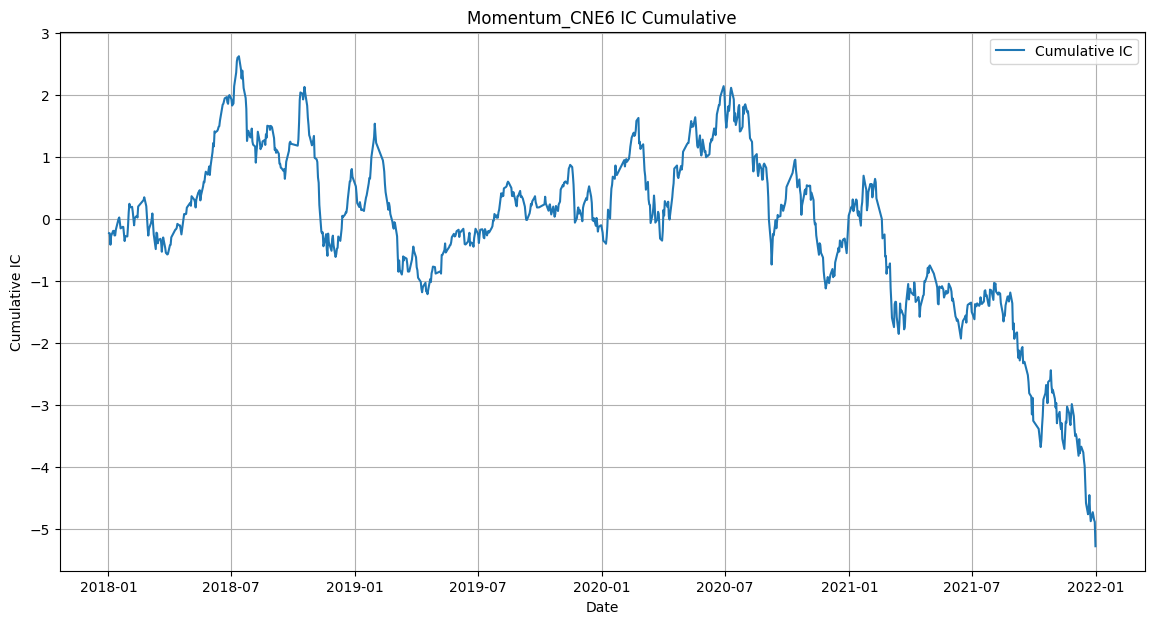

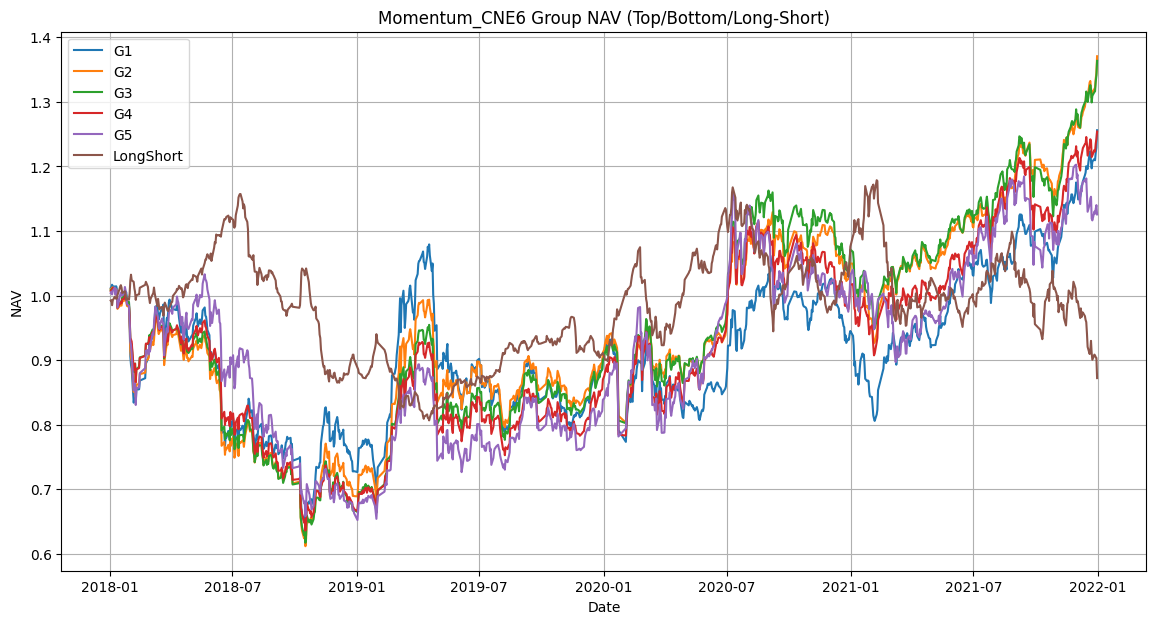


===== 回测因子: Size =====
IC: 0.003534 ICIR: 0.05549
Long-Short年化: 0.0243 最大回撤: 0.1168
IC: 0.003534 ICIR: 0.05549
Long-Short年化: 0.0243 最大回撤: 0.1168


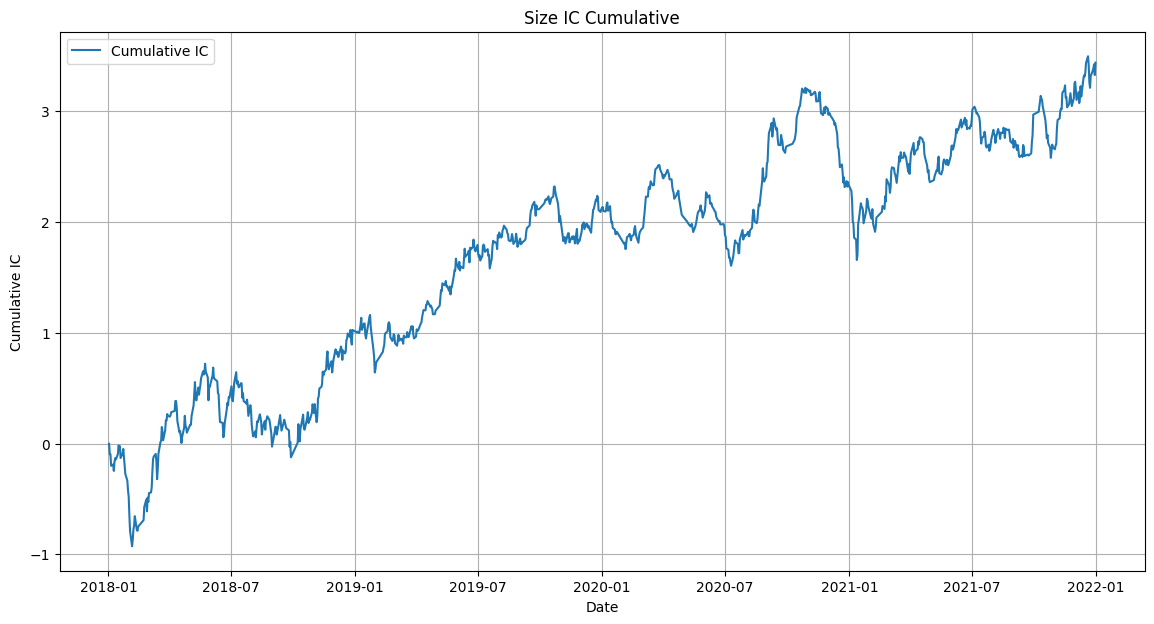

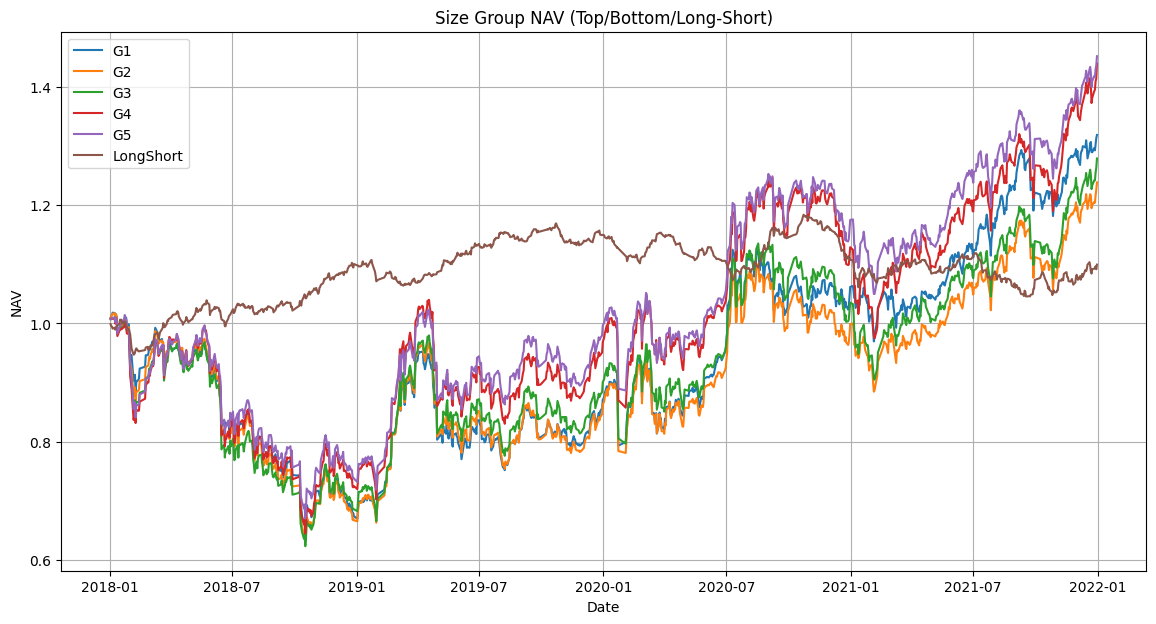

In [13]:
# ====== 读取 output 并做可视化回测（与 Barra_CSI300 风格一致） ======
factors_from_output = sorted([k for k in saved_factor_data.keys() if k in OUTPUT_DIR_MAP])

# 此处保留开关，便于与加载阶段配置联动/二次筛选
if ENABLE_FACTOR_FILTER:
    selected_factors = [f for f in factors_from_output if f in TARGET_FACTORS]
else:
    selected_factors = factors_from_output

if not selected_factors:
    print('没有可回测的因子：请检查 output 目录与 TARGET_FACTORS 设置。')
else:
    print(f'将回测 {len(selected_factors)} 个因子: {selected_factors}')

for factor_name in selected_factors:
    print(f'\n===== 回测因子: {factor_name} =====')
    res = saved_factor_data.get(factor_name)
    if res is None or res.empty:
        print(f'因子 {factor_name} 无可用数据，跳过。')
        continue

    if 'trade_date' not in res.columns:
        print(f'因子 {factor_name} 缺少 trade_date，跳过。')
        continue

    res = res.copy()
    res['trade_date'] = pd.to_datetime(res['trade_date'], errors='coerce')
    res = res.dropna(subset=['trade_date'])

    # 防御性处理：若落盘数据不含 next_return，则用 pctchange_eval 回填
    if 'next_return' not in res.columns:
        res = res.merge(
            pctchange_eval[['stock_code', 'trade_date', 'next_return']],
            on=['stock_code', 'trade_date'],
            how='left',
        )

    if 'next_return' not in res.columns:
        print(f'因子 {factor_name} 缺少 next_return，跳过。')
        continue

    # 二次时间过滤（与加载阶段一致，防止手工改参数后未重跑上一格）
    if ENABLE_DATE_FILTER:
        start_dt = pd.to_datetime(BT_START)
        end_dt = pd.to_datetime(BT_END)
        res = res[(res['trade_date'] >= start_dt) & (res['trade_date'] <= end_dt)]
        if res.empty:
            print(f'因子 {factor_name} 在区间 [{BT_START}, {BT_END}] 无数据，跳过。')
            continue

    factor_col = factor_name
    if factor_col not in res.columns:
        print(f'因子列 {factor_col} 不在结果中，尝试自动匹配...')
        candidate = [
            c
            for c in res.columns
            if c not in {'ts_code', 'stock_code', 'trade_date', 'next_return'} and pd.api.types.is_numeric_dtype(res[c])
        ]
        if not candidate:
            print(f'因子 {factor_name} 没有可用数值列，跳过。')
            continue
        factor_col = candidate[0]
        print(f'自动使用列 {factor_col} 作为因子值。')

    eval_input = res.dropna(subset=[factor_col, 'next_return'])
    if eval_input.empty:
        print(f'因子 {factor_name} 在当前筛选条件下无有效样本，跳过。')
        continue

    metrics = evaluate_factor(
        eval_input,
        factor_col=factor_col,
        return_col='next_return',
        ic_return_col='next_return',
        reverse=False,
    )

    ic_mean = float(metrics.get('ic_mean', float('nan')))
    ic_ir = float(metrics.get('icir', float('nan')))
    print('IC:', round(ic_mean, 6), 'ICIR:', round(ic_ir, 6))

    perf_map = metrics.get('perf', {})
    ls_perf = perf_map.get('LongShort', {}) if isinstance(perf_map, dict) else {}
    ls_ann = float(ls_perf.get('annual_return', float('nan'))) if isinstance(ls_perf, dict) else float('nan')
    ls_mdd = float(ls_perf.get('max_drawdown', float('nan'))) if isinstance(ls_perf, dict) else float('nan')
    print('Long-Short年化:', round(ls_ann, 4), '最大回撤:', round(ls_mdd, 4))

    ic_values = metrics.get('ic_values', [])
    ic_values = list(ic_values) if isinstance(ic_values, (list, tuple, pd.Series, np.ndarray)) else []
    trade_dates = sorted(pd.to_datetime(eval_input['trade_date'].dropna().unique()))
    plot_ic_curve(ic_values, trade_dates, title=f'{factor_name} IC Cumulative')

    nav_map = metrics.get('nav', {})
    if isinstance(nav_map, dict):
        plot_group_nav(nav_map, title=f'{factor_name} Group NAV (Top/Bottom/Long-Short)')
    else:
        print(f'因子 {factor_name} 的分组净值结果异常，跳过绘图。')

In [18]:
""" 
# ====== 计算因子收益率 v1 ======

# 已按你的要求固定使用该目录（按交易日一个pkl）
PCTCHANGE_DAILY_DIR = Path(r'F:/RYSE_Database/pctchange_daily_pkl')
FACTOR_RETURN_OUTPUT_ROOT = Path(r'./output')

# 可选：是否仅对回测筛选后的因子计算收益率
factor_names_for_ret = TARGET_FACTORS if ENABLE_FACTOR_FILTER else None

# 可选市值权重（使用已加载表）
market_cap_df = None
if 'tables' in globals() and isinstance(tables, dict) and 'ashareeodderivativeindicator' in tables:
    market_cap_df = tables['ashareeodderivativeindicator']

factor_ret_result = run_factor_return_pipeline(
    factor_data=saved_factor_data,
    pctchange_daily_dir=PCTCHANGE_DAILY_DIR,
    output_root=FACTOR_RETURN_OUTPUT_ROOT,
    selected_factors=factor_names_for_ret,
    start_date=BT_START if ENABLE_DATE_FILTER else None,
    end_date=BT_END if ENABLE_DATE_FILTER else None,
    buffer_days=BT_BUFFER_DAYS if ENABLE_DATE_FILTER else 0,
    market_cap_df=market_cap_df,
    market_cap_col='s_dq_mv',
    min_stocks=30,
 )

print('因子收益率输出文件:')
#print('-', factor_ret_result['factor_returns_csv'])
print('-', factor_ret_result['factor_returns_pkl'])
print('特异性收益输出文件:')
#print('-', factor_ret_result['specific_returns_csv'])
print('-', factor_ret_result['specific_returns_pkl'])

factor_returns_df = factor_ret_result.get('factor_returns')
if isinstance(factor_returns_df, pd.DataFrame):
    display(factor_returns_df.tail())
else:
    print('factor_returns 结果异常，请检查上游数据。')
    
"""

" \n# ====== 计算因子收益率 v1 ======\n\n# 已按你的要求固定使用该目录（按交易日一个pkl）\nPCTCHANGE_DAILY_DIR = Path(r'F:/RYSE_Database/pctchange_daily_pkl')\nFACTOR_RETURN_OUTPUT_ROOT = Path(r'./output')\n\n# 可选：是否仅对回测筛选后的因子计算收益率\nfactor_names_for_ret = TARGET_FACTORS if ENABLE_FACTOR_FILTER else None\n\n# 可选市值权重（使用已加载表）\nmarket_cap_df = None\nif 'tables' in globals() and isinstance(tables, dict) and 'ashareeodderivativeindicator' in tables:\n    market_cap_df = tables['ashareeodderivativeindicator']\n\nfactor_ret_result = run_factor_return_pipeline(\n    factor_data=saved_factor_data,\n    pctchange_daily_dir=PCTCHANGE_DAILY_DIR,\n    output_root=FACTOR_RETURN_OUTPUT_ROOT,\n    selected_factors=factor_names_for_ret,\n    start_date=BT_START if ENABLE_DATE_FILTER else None,\n    end_date=BT_END if ENABLE_DATE_FILTER else None,\n    buffer_days=BT_BUFFER_DAYS if ENABLE_DATE_FILTER else 0,\n    market_cap_df=market_cap_df,\n    market_cap_col='s_dq_mv',\n    min_stocks=30,\n )\n\nprint('因子收益率输出文件:')\n#print('-', f

In [17]:
# ====== 计算因子收益率 v2 ======

# 1) 行业数据（你主流程里已加载）
industry_df = tables["ashareciticsindustry"]

# 2) 因子数据（你前面已生成并可按需筛选）
factor_data = saved_factor_data
selected = TARGET_FACTORS if ENABLE_FACTOR_FILTER else None

# 3) 运行 v2 因子收益率计算
ret_v2 = run_factor_return_pipeline_v2(
    factor_data=factor_data,
    industry_df=industry_df,
    pctchange_daily_dir=Path(r"F:/RYSE_Database/pctchange_daily_pkl"),
    output_root=Path(r"./output"),
    selected_factors=selected,
    start_date=BT_START if ENABLE_DATE_FILTER else None,
    end_date=BT_END if ENABLE_DATE_FILTER else None,
    buffer_days=BT_BUFFER_DAYS if ENABLE_DATE_FILTER else 0,
    market_cap_df=tables.get("ashareeodderivativeindicator"),
    market_cap_col="s_dq_mv",
    min_stocks=50,
    weight_scheme="cap",  # 可改: "sqrt_cap" / "equal"
)

print("因子收益输出:", ret_v2["factor_returns_pkl"])
print("特异性收益输出:", ret_v2["specific_returns_pkl"])
display(ret_v2["factor_returns"].tail())

因子收益输出: output\factor_daily_returns_v2.pkl
特异性收益输出: output\specific_returns_long_v2.pkl


,Size,Momentum_CNE6,Intercept
trade_date,,,
2021-12-27,0.049904,0.293285,0.461501
2021-12-28,-0.039363,-0.160353,1.123559
2021-12-29,0.024264,-0.013807,-0.211310
2021-12-30,-0.123208,-0.021886,-0.088432
2021-12-31,-0.035448,-1.120937,1.672874


In [ ]:
# ====== 风险模型单日验证（X/F/Delta/V） ======

def build_exposure_panel_from_saved(saved_factor_data, industry_df):
    panel = None
    for fac_name, df in saved_factor_data.items():
        if df is None or df.empty or not {'stock_code', 'trade_date'}.issubset(df.columns):
            continue
        tmp = df.copy()
        tmp['trade_date'] = pd.to_datetime(tmp['trade_date'], errors='coerce')
        tmp = tmp.dropna(subset=['trade_date'])

        fac_col = fac_name if fac_name in tmp.columns else None
        if fac_col is None:
            cand = [
                c for c in tmp.columns
                if c not in {'stock_code', 'trade_date', 'next_return', 'pctchange', 'icfactor', 'ts_code'}
                and pd.api.types.is_numeric_dtype(tmp[c])
            ]
            if not cand:
                continue
            fac_col = cand[0]

        tmp = tmp[['stock_code', 'trade_date', fac_col]].rename(columns={fac_col: fac_name})
        tmp = tmp.drop_duplicates(['stock_code', 'trade_date'], keep='last')
        panel = tmp if panel is None else panel.merge(tmp, on=['stock_code', 'trade_date'], how='outer')

    if panel is None:
        raise ValueError('无法从 saved_factor_data 构建暴露面板')

    ind_cols = ['stock_code', 'trade_date', 'L1name'] if 'L1name' in industry_df.columns else ['stock_code', 'trade_date', 'industry_name']
    ind = industry_df[ind_cols].copy()
    ind['trade_date'] = pd.to_datetime(ind['trade_date'], errors='coerce')
    if 'L1name' in ind.columns:
        ind = ind.rename(columns={'L1name': 'industry_name'})

    panel = panel.merge(ind, on=['stock_code', 'trade_date'], how='left')
    panel['industry_name'] = panel['industry_name'].fillna('未知行业')
    panel = panel.sort_values(['trade_date', 'stock_code']).reset_index(drop=True)
    return panel

# 使用 v2 输出作为风险模型输入
factor_returns = ret_v2['factor_returns'].copy()
specific_returns_wide = to_specific_returns_wide(ret_v2['specific_returns'])
exposure_panel = build_exposure_panel_from_saved(saved_factor_data, tables['ashareciticsindustry'])

if ENABLE_DATE_FILTER:
    candidate = pd.to_datetime(BT_END)
    target_date = factor_returns.index[factor_returns.index <= candidate].max()
else:
    target_date = factor_returns.index.max()

risk_pack = build_risk_matrices_for_date(
    factor_returns=factor_returns,
    specific_returns_wide=specific_returns_wide,
    exposure_panel=exposure_panel,
    target_date=target_date,
    include_industry=False,  # 当前 v2 因子收益默认是风格因子口径
    cov_days=252,
    nw_lag=5,
    mc=200,
    alpha=1.5,
 )

print('target_date =', pd.to_datetime(target_date).date())
print('X shape =', risk_pack['X'].shape)
print('F shape =', risk_pack['F'].shape)
print('Delta shape =', risk_pack['Delta'].shape)
print('V shape =', risk_pack['V'].shape)
display(risk_pack['V'].head())

In [ ]:
# ====== 批量生成风险快照（X/F/Delta/V） ======
from pathlib import Path
import pandas as pd

# 1) 准备输入：factor_returns / specific_returns_wide / exposure_panel
factor_returns = ret_v2["factor_returns"].copy()
specific_returns_wide = to_specific_returns_wide(ret_v2["specific_returns"])
exposure_panel = build_exposure_panel_from_saved(saved_factor_data, tables["ashareciticsindustry"])

# 2) 直接传 rebalance_dates（示例：月频，取时间区间内每21个交易日）
all_dates = sorted(pd.to_datetime(factor_returns.index.unique()))
if ENABLE_DATE_FILTER:
    all_dates = [d for d in all_dates if (d >= pd.to_datetime(BT_START)) and (d <= pd.to_datetime(BT_END))]

step = 21  # 月频；周频可改 5，日频可改 1
rebalance_dates = all_dates[::step]

# 2) 手动指定 10 个调仓日（必须在 factor_returns.index 里）
#rebalance_dates = pd.to_datetime([
#    "2018-01-31", "2018-03-30", "2018-05-31", "2018-07-31", "2018-09-28",
#    "2018-11-30", "2019-01-31", "2019-03-29", "2019-05-31", "2019-07-31",
#])

# 可选：自动过滤掉不在索引中的日期，避免报错
#valid_set = set(pd.to_datetime(factor_returns.index))
#rebalance_dates = [d for d in rebalance_dates if d in valid_set]


# 3) 批量生成并落盘到 ./output/risk_snapshots（仅 pkl）
snapshot_summary = build_risk_snapshots_for_rebalance_dates(
    factor_returns=factor_returns,
    specific_returns_wide=specific_returns_wide,
    exposure_panel=exposure_panel,
    rebalance_dates=rebalance_dates,
    snapshot_dir=Path("./output/risk_snapshots"),
    include_industry=False,  # 当前 ret_v2 因子收益通常是风格口径，建议先 False
    cov_days=252,
    nw_lag=5,
    mc=200,
    alpha=1.5,
    continue_on_error=True,
)

print("快照生成完成：", len(snapshot_summary), "期")
display(snapshot_summary.tail(10))

In [ ]:
# ====== 组合优化 + 风险归因（最小接入） ======
from portfolio_optimizer import optimize_portfolio, OptimizeConfig
from risk_attribution import attribute_portfolio_risk

# 依赖上一单元产出的 risk_pack（含 X/F/Delta/V）
X = risk_pack['X']
F = risk_pack['F']
Delta = risk_pack['Delta']
V = risk_pack['V']

# 基准权重：等权（如有真实指数权重，可替换）
benchmark_weights = pd.Series(1.0 / len(X), index=X.index)

# alpha 示例：使用 Size 暴露作为示例信号（可替换成你的 alpha）
alpha_signal = X['Size'] if 'Size' in X.columns else pd.Series(0.0, index=X.index)

opt_res = optimize_portfolio(
    strategy_type='max_active_return',
    exposure_matrix=X,
    total_risk_matrix=V,
    benchmark_weights=benchmark_weights,
    alpha_signal=alpha_signal,
    prev_weights=benchmark_weights,
    config=OptimizeConfig(
        risk_aversion=0.25,
        single_stock_cap=0.05,
        active_weight_cap=0.02,
        industry_dev_limit=0.01,
        size_restriction_max_active_return=0.05,
        max_turnover=0.60,
        transaction_cost=0.0015,
    ),
)

att_res = attribute_portfolio_risk(
    weights=opt_res['weights'],
    exposure_matrix=X,
    factor_cov=F,
    specific_var_diag=Delta,
    benchmark_weights=benchmark_weights,
)

print('优化状态:', opt_res['status'])
print('目标函数:', opt_res['objective'])
print('组合权重和:', float(opt_res['weights'].sum()))
print('主动权重绝对和:', float(opt_res['active_weights'].abs().sum()))

display(opt_res['weights'].sort_values(ascending=False).head(10).to_frame('weight'))
display(att_res['summary'].to_frame('value'))

In [ ]:
# ====== 组合优化 + 风险归因（增强版：交易约束/风格中性/因子明细/时序） ======
from src.portfolio_optimizer import (
    ExtendedOptimizeConfig,
    optimize_portfolio_with_constraints,
)
from src.risk_attribution import (
    factor_risk_contributions,
    attribute_risk_over_time,
)

# 依赖上一单元产出的 risk_pack（X/F/Delta/V）
X = risk_pack['X']
F = risk_pack['F']
Delta = risk_pack['Delta']
V = risk_pack['V']

reb_dt = pd.to_datetime(target_date)
benchmark_weights = pd.Series(1.0 / len(X), index=X.index)
alpha_signal = X['Size'] if 'Size' in X.columns else pd.Series(0.0, index=X.index)

# 1) 增强版优化：带交易约束与风格中性模板
opt_ext = optimize_portfolio_with_constraints(
    strategy_type='max_active_return',
    exposure_matrix=X,
    total_risk_matrix=V,
    benchmark_weights=benchmark_weights,
    alpha_signal=alpha_signal,
    prev_weights=benchmark_weights,
    config=ExtendedOptimizeConfig(
        risk_aversion=0.25,
        single_stock_cap=0.05,
        active_weight_cap=0.02,
        max_turnover=0.60,
        transaction_cost=0.0015,
        style_neutral_tolerance=0.02,
        industry_neutral_tolerance=0.01,
        buy_turnover_cap=0.40,
        sell_turnover_cap=0.40,
    ),
    enforce_style_neutral_template=True,
)

# 2) 因子粒度风险贡献明细
factor_detail = factor_risk_contributions(
    weights=opt_ext['weights'],
    exposure_matrix=X,
    factor_cov=F,
    benchmark_weights=benchmark_weights,
)

print('增强版优化状态:', opt_ext['status'])
print('目标函数:', opt_ext['objective'])
print('换手率(近似):', opt_ext['turnover'])
display(opt_ext['weights'].sort_values(ascending=False).head(10).to_frame('weight'))
display(factor_detail.head(15))

# 3) 时序归因示例（此处给出单期模板；可扩展为多期字典）
weights_by_date = pd.DataFrame([opt_ext['weights'].reindex(X.index).fillna(0.0).to_numpy()], index=[reb_dt], columns=X.index)
benchmark_by_date = pd.DataFrame([benchmark_weights.reindex(X.index).fillna(0.0).to_numpy()], index=[reb_dt], columns=X.index)

ts_attr = attribute_risk_over_time(
    weights_by_date=weights_by_date,
    exposure_by_date={reb_dt: X},
    factor_cov_by_date={reb_dt: F},
    specific_var_by_date={reb_dt: Delta},
    benchmark_by_date=benchmark_by_date,
)

print('时序归因期数:', len(ts_attr['summary_ts']))
display(ts_attr['summary_ts'])
display(ts_attr['factor_detail_ts'].head(20))